# From One Neuron to a Neural Network

Neural networks have a reputation for being hard. They aren't, at least not at the start. The single neuron you're about to build is something you have **already built**, under a different name, a fortnight ago.

This notebook follows one thread from beginning to end:

1. **What a single neuron actually is** — three ingredients, no magic
2. **Building one from scratch** in numpy, and training it
3. **The reveal** — a one-neuron network *is* logistic regression, and we'll prove it with identical numbers
4. **Where one neuron breaks** — a problem so simple you can do it in your head, that a single neuron genuinely cannot solve
5. **Adding a hidden layer** — the fix, and why it works
6. **When to actually use one**, which is less often than the hype suggests

We'll finish with a result that surprises people: on the Titanic data, a neural network with **257 parameters loses to a single neuron with 7**.

**What you need:** numpy, matplotlib, scikit-learn, and `titanic.csv` in the same folder.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wikipedia

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

print("Ready.")

Ready.


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

---
# Part 1 , What a neuron actually is

A neuron takes some numbers in, and puts one number out. Three ingredients:

**1. Weights.** Each input gets multiplied by a weight, which says how much that input matters. A big weight means "pay attention to this". A negative weight means "this pushes the answer the other way".

**2. A bias.** One extra number added on at the end. It shifts the whole thing up or down, and it's what lets the neuron be reluctant or eager regardless of its inputs.

**3. An activation function.** The weighted sum could be any number at all, so we squash it into something between 0 and 1 using the **sigmoid**. That's the S-curve you met with logistic regression.

Written out, the whole thing is:

    output = sigmoid( input1 × weight1 + input2 × weight2 + bias )

That's a neuron. Genuinely all of it.

In [2]:
def sigmoid(z):
    """Squash any number into the range 0 to 1."""
    return 1 / (1 + np.exp(-z))

# Look at the shape of it.
z = np.linspace(-8, 8, 200)

plt.figure(figsize=(7, 3.5))
plt.plot(z, sigmoid(z), lw=2)
plt.axhline(0.5, color='grey', ls=':')
plt.axhline(0, color='grey', ls=':')
plt.axhline(1, color='grey', ls=':')
plt.title('The sigmoid: any number in, 0 to 1 out')
plt.xlabel('weighted sum')
plt.ylabel('neuron output')
plt.show()

<Figure size 700x350 with 1 Axes>

In [4]:
def neuron(inputs, weights, bias):
    """One neuron. Multiply, add, squash."""
    return sigmoid(np.dot(inputs, weights) + bias)

# Set the weights by hand and see what it does.
w = np.array([2.0, 2.0])
b = -3.0

for inputs in [[0, 0], [0, 1], [1, 0], [1, 1]]:
    out = neuron(np.array(inputs), w, b)
    print(f"  inputs {inputs} -> {out:.4f}  (rounds to {int(round(out))})")

  inputs [0, 0] -> 0.0474  (rounds to 0)
  inputs [0, 1] -> 0.2689  (rounds to 0)
  inputs [1, 0] -> 0.2689  (rounds to 0)
  inputs [1, 1] -> 0.7311  (rounds to 1)


**Read what those hand-picked numbers do.** With weights of 2 and 2 and a bias of -3, the neuron only fires when *both* inputs are 1. Any single input gives 2, which isn't enough to overcome the -3 bias. Both inputs give 4, which is.

We just built a logical **AND** by hand.

The interesting question is whether the neuron can work those numbers out for itself.

---
# Part 2 , Training a neuron

Training means: start with random weights, see how wrong the output is, nudge the weights to be slightly less wrong, and repeat a few thousand times.

That nudging is **gradient descent**. The code below is the entire algorithm, and it's about eight lines.

In [5]:
def train_neuron(X, y, epochs=5000, learning_rate=0.5, seed=1):
    """Train one neuron with gradient descent."""
    rng = np.random.default_rng(seed)
    weights = rng.normal(0, 1, X.shape[1])   # start random
    bias = 0.0

    for _ in range(epochs):
        output = sigmoid(X @ weights + bias)   # what does it currently say?
        error = output - y                     # how wrong is that?
        weights -= learning_rate * (X.T @ error) / len(y)   # nudge
        bias -= learning_rate * error.mean()

    return weights, bias


# The four possible inputs to a two-input logic gate.
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)

# AND: only true when both are true.
y_and = np.array([0, 0, 0, 1], dtype=float)

w, b = train_neuron(X, y_and)

print("Learned weights: {:.3f}, {:.3f}".format(w[0], w[1]))
print("Learned bias:    {:.3f}".format(b))
print()
for inputs, target in zip(X, y_and):
    out = sigmoid(inputs @ w + b)
    print(f"  {inputs.astype(int)} -> {out:.4f}   (want {int(target)})")

Learned weights: 9.277, 9.277
Learned bias:    -14.085

  [0 0] -> 0.0000   (want 0)
  [0 1] -> 0.0081   (want 0)
  [1 0] -> 0.0081   (want 0)
  [1 1] -> 0.9887   (want 1)


**It found weights of 9.277 and 9.277, with a bias of -14.085.**

Same logic as the numbers we picked by hand, just more emphatic. Either input alone gives 9.277, which loses to the -14.085 bias. Both together give 18.554, which wins.

Nobody told it the rule. It started from random numbers and nudged its way there.

Try `y_or = np.array([0, 1, 1, 1])` and it learns OR just as happily.

---
# Part 3 , The reveal: you have built this before

Here's the thing worth pausing on.

A single neuron with a sigmoid activation, trained by gradient descent, is **mathematically identical to logistic regression**. Not similar. The same model, with different vocabulary attached.

| Neural network word | Logistic regression word |
|---|---|
| weights | coefficients |
| bias | intercept |
| activation function | the link function |
| training / epochs | fitting |

Let's not take that on trust. We'll train our from-scratch neuron on the Titanic data, then run scikit-learn's `LogisticRegression` on exactly the same split, and compare.

In [6]:
df = pd.read_csv('titanic.csv')

data = df.copy()
data['age'] = data['age'].fillna(data['age'].median())
data['sex_male'] = (data['sex'] == 'male').astype(int)

features = ['pclass', 'sex_male', 'age', 'sibsp', 'parch', 'fare']
X_t = data[features]
y_t = data['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X_t, y_t, test_size=0.2, random_state=42, stratify=y_t
)

# Neurons need scaled inputs, exactly like KNN and SVM did.
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Training rows:", len(X_train))

Training rows: 712


In [7]:
# Our own neuron, written from scratch above.
w = np.zeros(X_train_s.shape[1])
b = 0.0

for _ in range(20000):
    output = sigmoid(X_train_s @ w + b)
    error = output - y_train.values
    w -= 0.1 * (X_train_s.T @ error) / len(y_train)
    b -= 0.1 * error.mean()

scratch_predictions = (sigmoid(X_test_s @ w + b) >= 0.5).astype(int)
scratch_accuracy = accuracy_score(y_test, scratch_predictions)

# scikit-learn's logistic regression, same data, same scaling.
logistic = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logistic.fit(X_train, y_train)
logistic_accuracy = accuracy_score(y_test, logistic.predict(X_test))

print("Our neuron, written from scratch: {:.4f}".format(scratch_accuracy))
print("scikit-learn LogisticRegression:  {:.4f}".format(logistic_accuracy))

Our neuron, written from scratch: 0.8045
scikit-learn LogisticRegression:  0.8045


In [8]:
print("Weights our neuron learned:")
print(" ", np.round(w, 3))
print()
print("Coefficients scikit-learn learned:")
print(" ", np.round(logistic[-1].coef_[0], 3))

Weights our neuron learned:
  [-0.914 -1.316 -0.515 -0.294 -0.096  0.141]

Coefficients scikit-learn learned:
  [-0.894 -1.297 -0.501 -0.287 -0.094  0.146]


**Identical accuracy, 0.8045 both ways, and every weight agrees to within 0.02.**

They're the same model. Our eight lines of numpy and scikit-learn's battle-tested implementation arrived at the same place because there was only one place to arrive at.

The weights aren't *exactly* equal, and the reason is worth knowing: scikit-learn applies a small amount of **regularisation** by default, a gentle pull keeping weights near zero to discourage overfitting. Our version has none. That's why sklearn's numbers come out consistently a fraction smaller, every single one of them. Turn regularisation off and the two sets of weights agree to five decimal places.

> 💡 **Why this matters.** If somebody tells you they've applied a neural network to a problem, the first useful question is *how many layers*. A single-layer network is logistic regression wearing a more impressive hat, and there's nothing wrong with that, but it isn't deep learning.

---
# Part 4 , Where one neuron breaks

Now for the problem that famously stopped neural network research for over a decade.

**XOR**, exclusive or. True when *exactly one* input is true, false when both or neither are:

| Input A | Input B | XOR |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | **1** |
| 1 | 0 | **1** |
| 1 | 1 | 0 |

You can do that in your head. It's simpler than most things you've asked a computer to do this month.

Let's train our neuron on it, and give it four times as long as we gave the AND gate.

In [9]:
y_xor = np.array([0, 1, 1, 0], dtype=float)

w_xor, b_xor = train_neuron(X, y_xor, epochs=20000)

print("Learned weights: {:.3f}, {:.3f}".format(w_xor[0], w_xor[1]))
print("Learned bias:    {:.3f}".format(b_xor))
print()
for inputs, target in zip(X, y_xor):
    out = sigmoid(inputs @ w_xor + b_xor)
    print(f"  {inputs.astype(int)} -> {out:.4f}   (want {int(target)})")

accuracy = (np.round(sigmoid(X @ w_xor + b_xor)) == y_xor).mean()
print()
print("Accuracy: {:.2f}".format(accuracy))

Learned weights: 0.000, 0.000
Learned bias:    -0.000

  [0 0] -> 0.5000   (want 0)
  [0 1] -> 0.5000   (want 1)
  [1 0] -> 0.5000   (want 1)
  [1 1] -> 0.5000   (want 0)

Accuracy: 0.50


**Look at what happened. The weights collapsed to zero and every single output is 0.5000.**

The neuron didn't get it slightly wrong. It gave up completely and now answers "I don't know" to everything. 0.5 is a coin flip, and 50% accuracy on a two-class problem is exactly what guessing gets you.

More training won't help. It isn't stuck, it has found the genuine best answer available to it, and the best available answer is useless.

### Why, and it's visual

A single neuron draws **one straight line** and calls everything on one side 1, everything on the other 0. That's all it can ever do.

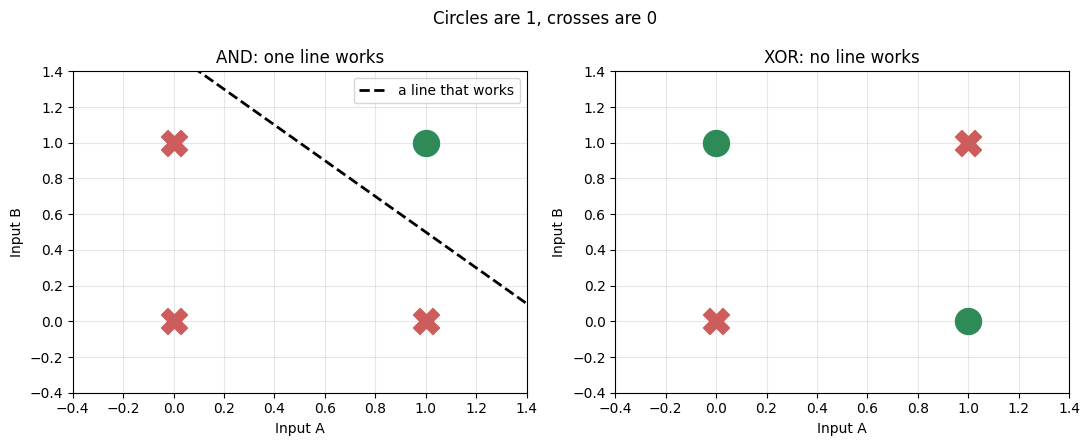

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (labels, title) in zip(axes, [(y_and, 'AND: one line works'),
                                      (y_xor, 'XOR: no line works')]):
    for point, label in zip(X, labels):
        ax.scatter(point[0], point[1], s=350,
                   c='seagreen' if label == 1 else 'indianred',
                   marker='o' if label == 1 else 'X', zorder=3)
    ax.set_xlim(-0.4, 1.4); ax.set_ylim(-0.4, 1.4)
    ax.set_xlabel('Input A'); ax.set_ylabel('Input B')
    ax.set_title(title)
    ax.grid(alpha=0.3)

# A line that separates the AND data perfectly.
line = np.linspace(-0.4, 1.4, 10)
axes[0].plot(line, 1.5 - line, 'k--', lw=2, label='a line that works')
axes[0].legend(loc='upper right')

plt.suptitle('Circles are 1, crosses are 0')
plt.tight_layout()
plt.show()

**On the left**, one dashed line cleanly separates the single circle from the three crosses. A neuron can find that line, and it did.

**On the right**, the two circles sit on opposite corners, and so do the two crosses. Try to draw one straight line with both circles on one side. You can't. No such line exists.

This is what **linearly separable** means, and it's the entire limitation of a single neuron.

> ❗**A bit of history worth knowing.** In 1969 Minsky and Papert published exactly this argument in a book called *Perceptrons*. It was correct, and it was so discouraging that neural network funding largely dried up for years, a period now called the first "AI winter". The fix already existed in principle, but it took until the 1980s to become practical.

---
# Part 5 , The fix: a hidden layer

If one line can't do it, use more than one line.

Instead of connecting inputs straight to the output, put a **layer of neurons in between**. Each of those hidden neurons draws its own line. The output neuron then combines their answers.

    inputs  ->  hidden layer  ->  output
      2            4 neurons        1

Now the network can carve the space into regions rather than halves. That's a **multi-layer perceptron**, or MLP.

We'll use scikit-learn's version rather than hand-writing the training, because training multiple layers needs backpropagation and that's a notebook of its own.

In [11]:
mlp_xor = MLPClassifier(
    hidden_layer_sizes=(4,),      # one hidden layer, four neurons
    activation='tanh',
    max_iter=20000,
    learning_rate_init=0.1,
    random_state=0,
)
mlp_xor.fit(X, y_xor)

print("Accuracy: {:.2f}".format(mlp_xor.score(X, y_xor)))
print()
probabilities = mlp_xor.predict_proba(X)[:, 1]
for inputs, prob, target in zip(X, probabilities, y_xor):
    print(f"  {inputs.astype(int)} -> {prob:.4f}   (want {int(target)})")

Accuracy: 1.00

  [0 0] -> 0.0009   (want 0)
  [0 1] -> 0.9914   (want 1)
  [1 0] -> 0.9922   (want 1)
  [1 1] -> 0.0112   (want 0)


**Solved.** 100% accuracy, and the probabilities are confident: 0.0009 and 0.0112 for the zeros, 0.9914 and 0.9922 for the ones.

Same data, same optimiser, same idea. The only change was inserting four neurons in the middle.

### How big does the hidden layer need to be?

Two hidden neurons is the theoretical minimum for XOR. Let's see whether the theory survives contact with reality.

In [12]:
for size in [(2,), (4,), (8,)]:
    solved = 0
    for seed in range(10):
        m = MLPClassifier(hidden_layer_sizes=size, activation='tanh',
                          max_iter=20000, learning_rate_init=0.1, random_state=seed)
        m.fit(X, y_xor)
        if m.score(X, y_xor) == 1.0:
            solved += 1
    print(f"  hidden layer of {size[0]}: solved {solved}/10 random starts")

  hidden layer of 2: solved 6/10 random starts
  hidden layer of 4: solved 10/10 random starts
  hidden layer of 8: solved 10/10 random starts


**Two neurons only works 6 times out of 10.** Four works every time.

The theoretical minimum is genuinely two, but the network starts from random weights and with only two neurons it often lands somewhere it can't climb out of. A bit of extra capacity gives it more routes to a good answer.

> 💡 **A practical habit.** When a network fails to learn something you're confident it should, try a slightly wider layer and a different random seed before concluding the problem is impossible. Bad luck at initialisation looks exactly like a hard problem.

---
# Part 6 , Counting the parts

It's worth seeing how small these networks actually are, because "neural network" sounds enormous.

In [13]:
print("XOR network:  2 inputs -> 4 hidden -> 1 output")
print("  weight matrices:", [c.shape for c in mlp_xor.coefs_])
print("  biases:         ", [b.shape for b in mlp_xor.intercepts_])

total = sum(c.size for c in mlp_xor.coefs_) + sum(b.size for b in mlp_xor.intercepts_)
print("  total numbers to learn:", total)

XOR network:  2 inputs -> 4 hidden -> 1 output
  weight matrices: [(2, 4), (4, 1)]
  biases:          [(4,), (1,)]
  total numbers to learn: 17


**17 numbers.** That's the entire network that solved a problem a single neuron found impossible.

For scale: a single neuron on our Titanic data has 6 weights plus 1 bias, so **7 numbers**. Modern language models have hundreds of billions. The idea doesn't change, only the count.

---
# Part 7 , Now try it on real data, and be ready for a surprise

XOR is a clean demonstration. Titanic is a real problem. Let's throw a proper multi-layer network at it: two hidden layers, sixteen neurons then eight.

In [17]:
mlp_unscaled = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=2000, random_state=42)
mlp_unscaled.fit(X_train, y_train)

mlp = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(16,8), max_iter=2000, random_state=42)
)
mlp.fit(X_train, y_train)

print("MLP without scaling: {:.4f}".format(accuracy_score(y_test, mlp_unscaled.predict(X_test))))
print("MLP with scaling:    {:.4f}".format(accuracy_score(y_test, mlp.predict(X_test))))

MLP without scaling: 0.7877
MLP with scaling:    0.7989


Scaling helps, as it did for KNN and SVM. Neural networks measure things by multiplying weights, so a column running to 512 shouts over a column running to 8.

Now the comparison that matters.

In [18]:
baseline = (df['survived'] == 0).mean()
sex_rule = ((df['sex'] == 'female').astype(int) == df['survived']).mean()
mlp_accuracy = accuracy_score(y_test, mlp.predict(X_test))

network = mlp[-1]
mlp_params = sum(c.size for c in network.coefs_) + sum(b.size for b in network.intercepts_)

print("Predict everyone died        : {:.4f}   (0 parameters)".format(baseline))
print("Women live, men die          : {:.4f}   (0 parameters)".format(sex_rule))
print("One neuron / logistic        : {:.4f}   (7 parameters)".format(logistic_accuracy))
print("MLP, two hidden layers       : {:.4f}   ({} parameters)".format(mlp_accuracy, mlp_params))

Predict everyone died        : 0.6162   (0 parameters)
Women live, men die          : 0.7868   (0 parameters)
One neuron / logistic        : 0.8045   (7 parameters)
MLP, two hidden layers       : 0.7989   (257 parameters)


**The neural network lost.**

257 parameters, two hidden layers, and it scores **0.7989** against the single neuron's **0.8045**. It barely beats one line of logic about sex.

This is not a mistake, and it's the most useful thing in the notebook.

**Why it happened:** the Titanic pattern is close to linear. Being female raises your chances, being in a lower class lowers them, and those effects mostly just add up. A straight line captures that well. The extra layers had nothing left to find, so all they added was more parameters to fit on 712 rows, which is a good way to learn noise.

**When neural networks genuinely win:**

- The pattern is strongly non-linear, like XOR
- There's a lot of data, tens of thousands of rows and up
- The features interact in complicated ways
- The raw input is images, audio or text, where the useful features aren't in columns yet

**When they don't:**

- Small tabular datasets, which is most business data
- When you need to explain the decision, since 257 numbers explain nothing
- When a simpler model already does the job

> ❗**The honest summary.** On tabular data of this size, logistic regression and gradient-boosted trees usually beat neural networks. Deep learning earned its reputation on images, audio and language, not on spreadsheets.

---
---
# Part 8 , Your turn

## Challenge 1 , Teach a neuron the other gates

You've seen AND learned. Try the rest.

In [20]:
# Lesson:
#   w, b = train_neuron(X, y, epochs=5000)
#   sigmoid(X @ w + b) gives the outputs
# X is already defined as the four input combinations.

# --- YOUR CODE ---
# 1. Train a neuron on OR    -> [0, 1, 1, 1]
# 2. Train a neuron on NAND  -> [1, 1, 1, 0]
# 3. Print the learned weights and outputs for each.
# 4. Both should work. Looking at the picture in Part 4, why?
# The four possible inputs to a two-input logic gate.
for name, targets in [("OR",   np.array([0, 1, 1, 1], dtype=float)),
                      ("NAND", np.array([1, 1, 1, 0], dtype=float))]:
    w_g, b_g = train_neuron(X, targets, epochs=5000)
    outputs = sigmoid(X @ w_g + b_g)
    correct = np.all(np.round(outputs) == targets)
    print(f"{name}: weights {w_g.round(2)}, bias {b_g:.2f}, all correct: {correct}")
    for inputs, out, target in zip(X, outputs, targets):
        print(f"    {inputs.astype(int)} -> {out:.4f} (want {int(target)})")
    print()



OR: weights [10.54 10.54], bias -4.81, all correct: True
    [0 0] -> 0.0081 (want 0)
    [0 1] -> 0.9968 (want 1)
    [1 0] -> 0.9968 (want 1)
    [1 1] -> 1.0000 (want 1)

NAND: weights [-9.27 -9.27], bias 14.08, all correct: True
    [0 0] -> 1.0000 (want 1)
    [0 1] -> 0.9919 (want 1)
    [1 0] -> 0.9919 (want 1)
    [1 1] -> 0.0114 (want 0)



## Challenge 2 , How wide does XOR need to be?

Part 5 tested 2, 4 and 8 hidden neurons. Fill in the gap.

In [ ]:
# Lesson:
#   MLPClassifier(hidden_layer_sizes=(n,), activation='tanh',
#                 max_iter=20000, learning_rate_init=0.1, random_state=seed)
# Loop over several seeds and count how many reach 100%.

# --- YOUR CODE ---
# 1. Try hidden layers of 1, 2, 3, 4, 5 neurons.
# 2. For each, count how many of 10 random seeds solve XOR.
# 3. What happens with just 1 hidden neuron, and why?




## Challenge 3 , Can you make the network win?

The MLP lost to a single neuron on Titanic. See if you can change that.

In [ ]:
# Lesson:
# Things you can vary:
#   hidden_layer_sizes=(32,), (64, 32), (8,) ...
#   activation='relu' or 'tanh' or 'logistic'
#   max_iter, learning_rate_init
# Always keep the StandardScaler in the pipeline.

# --- YOUR CODE ---
# 1. Try at least four different architectures.
# 2. Print each test accuracy against the 0.8045 to beat.
# 3. Did anything beat it? If not, what does that tell you about
#    this dataset rather than about neural networks?




---
# What to take away

1. **A neuron is three things:** weights, a bias, and an activation function.
2. **One neuron is logistic regression.** We proved it, identical accuracy and near-identical weights.
3. **One neuron can only draw one straight line**, which is why XOR defeats it.
4. **A hidden layer removes that limit**, and 17 numbers were enough to solve XOR.
5. **More capacity is not automatically better.** 257 parameters lost to 7 on real data.
6. **Scale your inputs.** Neural networks care, same as KNN and SVM.

> **Where this goes:** everything in modern AI is this, repeated. More layers, more neurons, cleverer connections between them. The neuron in Part 1 and the neuron inside a large language model do the same three things. What changed is how many of them there are and how they're wired together.

---
---
# SOLUTIONS

### Challenge 1 , The other gates

In [ ]:
for name, targets in [("OR",   np.array([0, 1, 1, 1], dtype=float)),
                      ("NAND", np.array([1, 1, 1, 0], dtype=float))]:
    w_g, b_g = train_neuron(X, targets, epochs=5000)
    outputs = sigmoid(X @ w_g + b_g)
    correct = np.all(np.round(outputs) == targets)
    print(f"{name}: weights {w_g.round(2)}, bias {b_g:.2f}, all correct: {correct}")
    for inputs, out, target in zip(X, outputs, targets):
        print(f"    {inputs.astype(int)} -> {out:.4f} (want {int(target)})")
    print()

# Both work, and for the same reason AND worked: they're linearly separable.
# Plot OR and you can draw one line with the single 0 on one side.
# Plot NAND and you can draw one line with the single 1 on one side.
# NAND's weights come out NEGATIVE, which is the neuron learning to fire
# when inputs are absent rather than present.
#
# XOR is the only one of the common two-input gates that isn't separable.

### Challenge 2 , How wide does XOR need to be?

In [ ]:
for n in [1, 2, 3, 4, 5]:
    solved = 0
    for seed in range(10):
        m = MLPClassifier(hidden_layer_sizes=(n,), activation='tanh',
                          max_iter=20000, learning_rate_init=0.1, random_state=seed)
        m.fit(X, y_xor)
        if m.score(X, y_xor) == 1.0:
            solved += 1
    print(f"  {n} hidden neuron(s): solved {solved}/10")

# With 1 hidden neuron it never works, and that makes sense: a single hidden
# neuron draws one line, passes its answer to the output neuron, and you are
# back to one line in total. It's a single neuron with extra steps.
#
# 2 is the theoretical minimum and works some of the time, depending on where
# the random weights happen to start.
# From 4 upwards it works every time. The extra neurons don't make the
# solution better, they make it easier to find.

### Challenge 3 , Can you make the network win?

In [ ]:
architectures = [(8,), (32,), (64, 32), (16, 8, 4), (100,)]

print("Target to beat: 0.8045 (a single neuron)\n")
for arch in architectures:
    model = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=arch, max_iter=3000, random_state=42)
    )
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    verdict = "beats it" if acc > logistic_accuracy else "loses"
    print(f"  {str(arch):12} -> {acc:.4f}   {verdict}")

# You may get one or two that edge past 0.8045, and if you do, treat it with
# suspicion. The test set is 179 passengers, so a single extra correct
# prediction moves the score by 0.0056. Trying ten architectures and keeping
# the best one is really just picking whichever got luckiest on those 179.
#
# The honest conclusion is about the DATA, not about neural networks:
# Titanic is small and its pattern is close to linear, so there is very little
# for extra layers to discover. That is a fact about this problem, and it's
# exactly why you always compare against a simple baseline.